# Gasto anual de medicamentos

Estimativa do gasto anual de medicamentos através de regressão dos dados de: https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv


In [1]:
import pandas as pd 

df = pd.read_csv('insurance.csv')

In [2]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


BMI = body mass index

children = number of childrens

smoker = if smokes or not

charges = atual medical charges

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


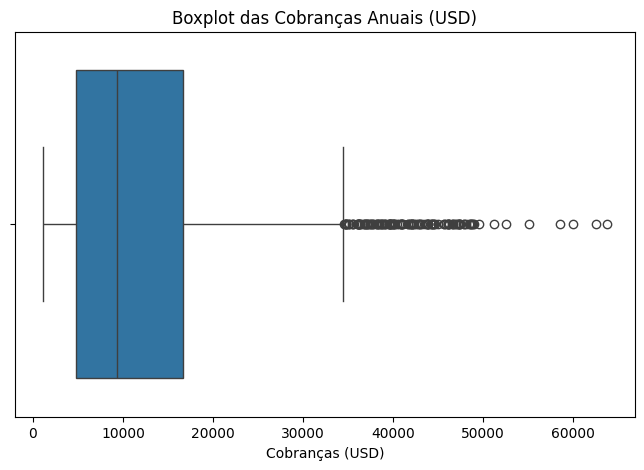

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize=(8,5))
sns.boxplot(x=df['charges'])
plt.xlabel('Cobranças (USD)')
plt.title('Boxplot das Cobranças Anuais (USD)')
plt.show()

In [6]:
import plotly.express as px
fig = px.histogram(df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribuição de Idade')
fig.update_layout(bargap=0.1)
fig.show()

In [7]:
fig = px.histogram(df,
                   x='bmi',
                   marginal='box',
                   nbins=47,
                   color_discrete_sequence=px.colors.qualitative.Prism,
                   title='Distribuição de Índice de Massa Corporal')
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
import numpy as np
limites = [0, 18.5, 24.9, 29.9, np.inf]
faixas_oms = ["Abaixo do peso", "Peso normal", "Sobrepeso", "Obesidade"]

df["Classificacao_OMS"] = pd.cut(
    df["bmi"], bins=limites, labels=faixas_oms, right=True
)

In [9]:
cores_faixas = {
    "Abaixo do peso": "#5bc0de",  # Azul claro
    "Peso normal": "#5cb85c",  # Verde
    "Sobrepeso": "#f0ad4e",  # Laranja/Amarelo
    "Obesidade": "#d9534f",  # Vermelho
}

In [10]:
fig = px.histogram(
    df,
    x="bmi",
    marginal="box",
    color="Classificacao_OMS",
    color_discrete_map=cores_faixas,
    category_orders={
        "Classificacao_OMS": faixas_oms
    },
    nbins=47,
    title="Distribuição de Índice de Massa Corporal (Padrão OMS)",
)


fig.update_layout(
    bargap=0.1,
    title_x=0.5,  
    xaxis_title="Índice de Massa Corporal (IMC)",
    yaxis_title="Contagem de Pessoas",
    legend_title="Classificação OMS",
)

fig.show()

In [11]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green','grey'],
                   nbins=47,
                   title='Distribuição de Cobranças (USD)')
fig.update_layout(bargap=0.1)
fig.show()

In [12]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [13]:
fig = px.histogram(df, 
             x='smoker', 
             color='sex', 
             title = 'Fumantes',
             )

fig.update_layout(
    bargap=0.1,
    title_x=0.5,  
    xaxis_title="Fumantes",
    yaxis_title="Contagem de Pessoas",
    legend_title="Fumantes",
)

In [14]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Idade vs Cobranças')

fig.update_traces(marker_size=5)
fig.show()

In [15]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='IMC vs Cobranças')

fig.update_traces(marker_size=5)
fig.show()

In [16]:
px.violin(df, x='children', y='charges')

In [17]:
df.charges.corr(df.age)

np.float64(0.2990081933306476)

In [18]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362895)

In [19]:
df.charges.corr(df.children)

np.float64(0.06799822684790478)

In [20]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = df.smoker.map(smoker_values)
df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [21]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

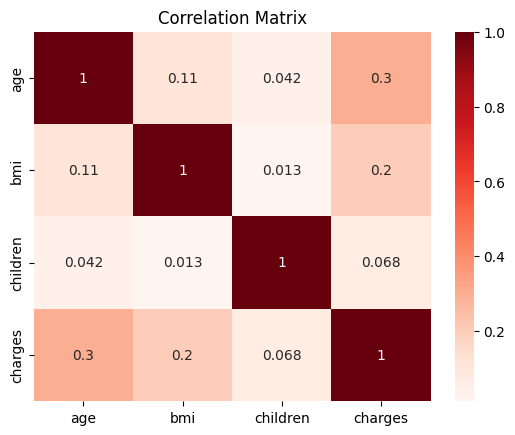

In [22]:
sns.heatmap(df.corr(numeric_only=True),
            cmap='Reds',
            annot=True)
plt.title("Correlation Matrix")

## Linear Regression

In [23]:
nao_fumante_df = df[df.smoker == 'no']

<Axes: title={'center': 'Idade vs Cobranças'}, xlabel='age', ylabel='charges'>

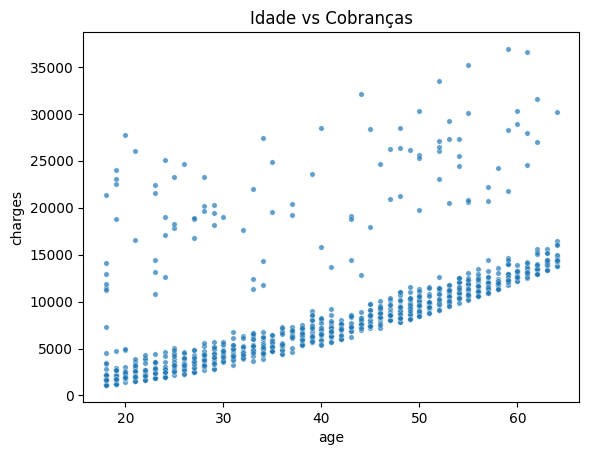

In [24]:
plt.title('Idade vs Cobranças')
sns.scatterplot(data=nao_fumante_df, x='age', y='charges', alpha=0.7, s=15)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()

In [27]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [28]:
inputs = nao_fumante_df[['age']]
targets = nao_fumante_df.charges
print('input.shape :', inputs.shape)
print('targets.shape :', targets.shape)

input.shape : (1064, 1)
targets.shape : (1064,)


In [29]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
model.predict(np.array([[23],[37],[61]]))

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [31]:
predictions = model.predict(inputs)

In [32]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [33]:
inputs

,age
1,18
2,28
3,33
4,32
5,31
...,...
1332,52
1333,50
1334,18
1335,18


In [34]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [35]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [36]:
model.coef_

array([267.24891283])

In [37]:
model.intercept_

np.float64(-2091.4205565650864)

In [38]:
def estimate_charges(age, w, b):
    return w*age + b

In [39]:
def try_parameters(w,b):
    ages = nao_fumante_df.age
    target = nao_fumante_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages,target, s=8, alpha=0.8);
    plt.xlabel('Idade');
    plt.ylabel('Cobranças')
    plt.legend(['Estimativa', 'Atual']);

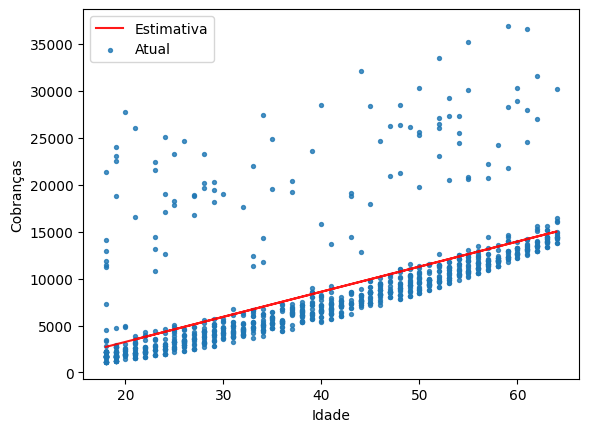

In [40]:
try_parameters(model.coef_,model.intercept_)

In [41]:
inputs, targets = nao_fumante_df[['age']], nao_fumante_df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 4662.505766636395


In [42]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [43]:
model2 = SGDRegressor(max_iter=1000, tol=1e-3)

In [44]:
model2.fit(inputs, targets)

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [45]:
predictions2 = model2.predict(inputs)

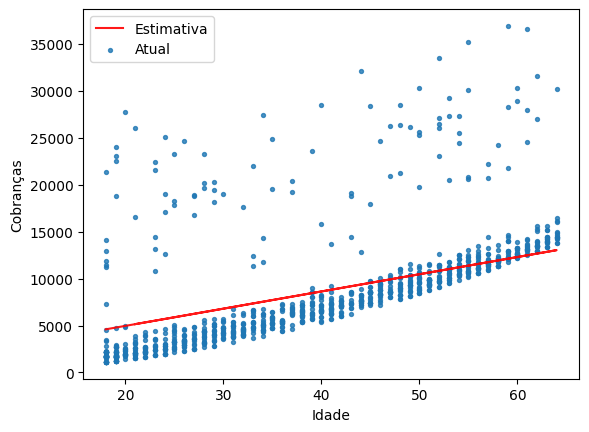

In [46]:
try_parameters(model2.coef_,model2.intercept_)

In [47]:
loss2 = rmse(targets, predictions2[-1])

print('Loss:', loss2)

Loss: 6835.260105957912


## Regressão Linear com Múltiplas Características

In [48]:
inputs, targets = nao_fumante_df[['age', 'bmi']], nao_fumante_df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 4662.3128354612945


In [49]:
nao_fumante_df.charges.corr(nao_fumante_df.bmi)

np.float64(0.0840365431283327)

In [50]:
fig = px.scatter(nao_fumante_df, x='bmi', y='charges', title='IMC vs Cobranças')
fig.update_traces(marker_size = 5)
fig.show()

In [51]:
nao_fumante_df.charges.corr(nao_fumante_df.children)

np.float64(0.13892870453542192)

In [52]:
px.violin(df, x='children', y='charges')

In [53]:
inputs, targets = nao_fumante_df[['age', 'bmi', 'children']], nao_fumante_df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 4608.470405038247


In [54]:
inputs, targets = df[['age', 'bmi', 'children']], df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 11355.317901125973


In [55]:
px.scatter(df, x='age', y='charges', color='smoker')

## Categorical Features

In [56]:
smoker_codes = {'no': 0, 'yes': 1}

df['smoker_code'] = df.smoker.map(smoker_codes)

In [57]:
df.charges.corr(df.smoker_code)

np.float64(0.787251430498478)

In [58]:
inputs, targets = df[['age', 'bmi', 'children', 'smoker_code']], df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 6056.439217188081


In [59]:
sex_codes = {'female': 0, 'male': 1}

In [60]:
df['sex_code'] = df.sex.map(sex_codes)

In [61]:
df.charges.corr(df.sex_code)

np.float64(0.057292062202025484)

In [62]:
inputs, targets = df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 6056.100708754546


## One-hot Encoding

<Axes: xlabel='region', ylabel='charges'>

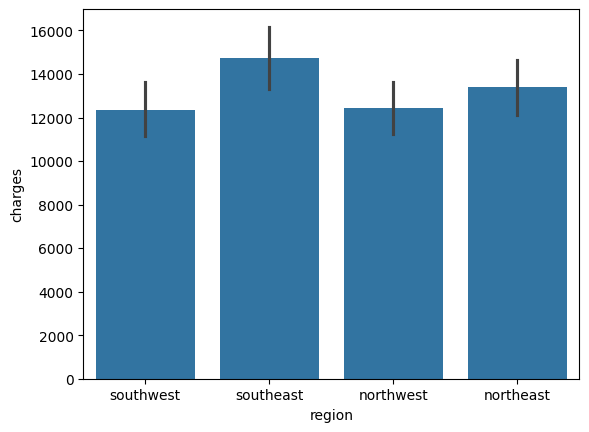

In [63]:
sns.barplot(data=df, x='region', y='charges')

In [64]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [65]:
one_hot = enc.transform(df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [66]:
df[['northeast', 'northwest', 'southeast', 'southweast']] = one_hot

In [67]:
df

,age,sex,bmi,children,smoker,region,charges,Classificacao_OMS,smoker_code,sex_code,northeast,northwest,southeast,southweast
0,19,female,27.900,0,yes,southwest,16884.92400,Sobrepeso,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,Obesidade,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,Obesidade,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,Peso normal,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,Sobrepeso,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,Obesidade,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,Obesidade,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,Obesidade,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,Sobrepeso,0,0,0.0,0.0,0.0,1.0


In [68]:
inputs, targets = df[['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southweast' ]], df[['charges']]

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)

print('Loss:', loss)

Loss: 6041.6796511744515


In [69]:
input_cols = model.feature_names_in_
pesos_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'peso': np.append(model.coef_, model.intercept_)
})
pesos_df

,feature,peso
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southweast,-373.041756
9,1,-12525.547811


In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(df[numeric_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [72]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [73]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [74]:
scaled_inputs = scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [75]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southweast' ]
categorical_data = df[cat_cols].values

In [76]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = df.charges

model = LinearRegression().fit(inputs,targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print("Loss:", loss)

Loss: 6041.6796511744515


In [77]:
pesos_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'peso': np.append(model.coef_, model.intercept_)
})
pesos_df.sort_values('peso', ascending=False)

,feature,peso
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southweast,-373.041756
7,southeast,-448.012814


In [78]:
new_costumers = [[28, 30, 2, 1, 0, 0, 1 , 0, 0.]]

In [79]:
scaler.transform([[28, 30, 2]])

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.79795355, -0.10882659,  0.75107928]])

In [80]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1, 0, 0, 1 , 0, 0.]])

array([29875.81463371])

In [81]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

In [82]:
numeric_cols = ['age', 'bmi', 'children']
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southweast' ]

In [83]:
X = df[numeric_cols + cat_cols]
y = df.charges

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

In [85]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ])



In [86]:

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', Lasso(alpha=0.1))
])

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [88]:
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [89]:
print("R² do modelo:", pipeline_lasso.score(X_test, y_test))

R² do modelo: 0.7696111311231152


In [90]:
coef_dict = dict(zip(X_train.columns, pipeline_lasso[-1].coef_))
print(f"Learned Coefficients:", coef_dict)
print(f"Intercept: {pipeline_lasso[-1].intercept_}")

Learned Coefficients: {'age': np.float64(3688.498042225225), 'bmi': np.float64(2090.795171191871), 'children': np.float64(513.9523810113363), 'smoker_code': np.float64(-23627.748165489855), 'sex_code': np.float64(9.494185734489328e-12), 'northeast': np.float64(-104.48284942266567), 'northwest': np.float64(5.900776943091925e-13), 'southeast': np.float64(-867.3447296313423), 'southweast': np.float64(0.0)}
Intercept: 32946.4247247609


['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southweast']

In [91]:
new_costumers = [[28, 30, 2, 1, 0, 0, 1 , 0, 0.]]
data_array = np.array(new_costumers)
transformador_numerico = scaler.transform(data_array[:, 0:3])
final = np.hstack((transformador_numerico, data_array[:, 3:]))
model.predict(final)

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([29875.81463599])

In [92]:
px.scatter(df, x='age', y='charges', color='smoker')

In [93]:
px.box(df, x='children', y='charges',color='smoker')

In [95]:
import joblib

joblib.dump(pipeline_lasso, 'lasso.joblib')


['lasso.joblib']

In [96]:
joblib.dump(model, 'regression.joblib')

['regression.joblib']